<a href="https://colab.research.google.com/github/PVC2020/Estatistica_basica/blob/main/estat_stica_computacional_em_python_capitulo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Medidas-Resumo

## 6. Medidas de Posição (Tendência Central)

Servem para encontrar o valor representativo em torno do qual os dados se distribuem.

*   **Média Aritmética (x̄)**: É a soma de todos os valores dividida pelo total de observações (n). É sensível a valores extremos (outliers).
    👉 **Fórmula:** x̄ = (x₁ + x₂ + ... + xₙ) / n

*   **Mediana (md)**: É o valor que divide os dados ordenados exatamente ao meio (50% abaixo, 50% acima). É uma medida **resistente** (não é distorcida por valores atípicos).

*   **Moda (mo)**: É o valor que aparece com maior frequência. Pode haver mais de uma moda (bimodal) ou nenhuma (amodal).

---

## 7. Medidas de Dispersão (Variabilidade)

Duas amostras podem ter a mesma média, mas comportamentos totalmente diferentes. As medidas de dispersão indicam o quanto os dados variam em torno da média.

*   **Desvio Médio (dm)**: Média das distâncias absolutas (ignorando sinal negativo) entre cada valor e a média geral.
    👉 **Fórmula:** dm = Σ |xᵢ - x̄| / n

*   **Variância (var)**: Média do quadrado das distâncias entre cada valor e a média. Como elevamos ao quadrado, a unidade de medida também fica ao quadrado (ex: kg², cm²), o que dificulta a interpretação.
    👉 **Fórmula:** var = Σ (xᵢ - x̄)² / n

*   **Desvio Padrão (dp)**: É a raiz quadrada da variância. É a medida mais utilizada porque **retorna os dados à unidade de medida original** (ex: kg, cm).
    👉 **Fórmula:** dp = √var

> ⚠️️ **Atenção (População vs. Amostra):** Neste capítulo do livro, as fórmulas dividem por 'n' (Variância Populacional). Mais à frente, quando formos trabalhar com *amostras*, a divisão será por 'n-1'.

In [1]:
import pandas as pd
import numpy as np

# Vamos reproduzir o exemplo dos grupos A e D do livro
df_notas = pd.DataFrame({
    'grupo_A': [3, 4, 5, 6, 7, 4, 5, 7, 2, 2, 4, 5, 6, 8],
    'grupo_D': [3, 5, 5, 5, 7, 1, 1, 3, 5, 7, 9, 0, 2, 1]
})

for coluna in ['grupo_A', 'grupo_D']:
    dados = df_notas[coluna]

    print(f"=== {coluna} ===")
    print("--- Medidas de Posição ---")
    # 1. Média
    media = dados.mean()
    print(f"Média:   {media:.4f}")

    # 2. Mediana
    mediana = dados.median()
    print(f"Mediana: {mediana}")

    # 3. Moda
    moda = dados.mode()[0]
    print(f"Moda:    {moda}\n")

    print("--- Medidas de Dispersão ---")
    # 4. Desvio Médio
    desvio_medio = (dados - media).abs().mean()
    print(f"Desvio Médio:  {desvio_medio:.4f}")

    # 5. Variância (ddof=0 para população)
    variancia = dados.var(ddof=0)
    print(f"Variância:     {variancia:.4f}")

    # 6. Desvio Padrão (ddof=0 para população)
    desvio_padrao = dados.std(ddof=0)
    print(f"Desvio Padrão: {desvio_padrao:.4f}")
    print("\n" + "="*20 + "\n")

=== grupo_A ===
--- Medidas de Posição ---
Média:   4.8571
Mediana: 5.0
Moda:    4

--- Medidas de Dispersão ---
Desvio Médio:  1.4490
Variância:     3.1224
Desvio Padrão: 1.7670


=== grupo_D ===
--- Medidas de Posição ---
Média:   3.8571
Mediana: 4.0
Moda:    5

--- Medidas de Dispersão ---
Desvio Médio:  2.2857
Variância:     6.8367
Desvio Padrão: 2.6147




## 8. Quantis Empíricos (Separatrizes)

Enquanto a média e a mediana resumem o centro dos dados, os **quantis** (ou separatrizes) dividem os dados em partes iguais (quando ordenados). Servem para entender a distribuição e são menos afetados por valores extremos (outliers).

*   **Quartis (Dividem em 4 partes de 25%):**
    *   $Q_1$ (1º Quartil / 25º Percentil): 25% dos dados estão abaixo dele.
    *   $Q_2$ (2º Quartil / 50º Percentil): É a própria Mediana. 50% abaixo.
    *   $Q_3$ (3º Quartil / 75º Percentil): 75% dos dados estão abaixo dele.
*   **Decis:** Dividem em 10 partes de 10%.
*   **Percentis:** Dividem em 100 partes de 1%.

> **Medida de Dispersão Robusta:**  
> **Distância Interquartil ($dq$ ou $IQR$)**: $IQR = Q_3 - Q_1$  
> É o tamanho do "miolo" onde se concentram os 50% dos dados centrais. É altamente resistente a outliers (como o valor 67 no exemplo do livro).

**Os "Cinco Números" da Distribuição Simétrica:**
O resumo ideal dos dados sem depender da média é feito pelos 5 números: `Mínimo`, `$Q_1$`, `$Q_2$ (Mediana)`, `$Q_3$`, `Máximo`.
* Em distribuições normais/simétricas, as distâncias entre eles são harmônicas.
* O comando `df.describe()` no Pandas faz exatamente a entrega desses 5 números (igual ao SPlus/Minitab no livro).

In [3]:
import numpy as np
import pandas as pd

print("--- EXEMPLO 3.5: Dados Brutos (Os 9 valores) ---")
# Criando a série de dados do exemplo
X = pd.Series([15, 5, 3, 8, 10, 2, 7, 11, 12,12,324,346,7567,3,3,23,65,12,564,75,75,88,11,1,0,2,4])

# Para obtermos os 5 números rapidamente:
resumo_5_numeros = X.describe()[['min', '25%', '50%', '75%', 'max']]
print("Os Cinco Números:")
print(resumo_5_numeros)

# Calculando a Distância Interquartil (IQR)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
print(f"\nDistância Interquartil (dq): {IQR}")
print(f"O 95º Percentil seria: {X.quantile(0.95)}")

print("\n--------------------------------------------------\n")

print("--- O Efeito do Outlier (Adicionando o 67) ---")
# O livro adiciona um valor discrepante (67)
X_outlier = pd.concat([X, pd.Series([67])], ignore_index=True)

# Note como a média explode de 8.1 para 14, mas a mediana quase não se move!
print(f"Dados originais -> Média: {X.mean():.1f} | Mediana: {X.median()}")
print(f"Com o 67      -> Média: {X_outlier.mean():.1f} | Mediana: {X_outlier.median()}")

--- EXEMPLO 3.5: Dados Brutos (Os 9 valores) ---
Os Cinco Números:
min       0.0
25%       3.5
50%      11.0
75%      70.0
max    7567.0
dtype: float64

Distância Interquartil (dq): 66.5
O 95º Percentil seria: 498.59999999999985

--------------------------------------------------

--- O Efeito do Outlier (Adicionando o 67) ---
Dados originais -> Média: 342.5 | Mediana: 11.0
Com o 67      -> Média: 332.7 | Mediana: 11.5


In [4]:
print("--- EXEMPLO 3.6: Quantis em Tabelas de Frequência (Interpolação Linear) ---")
# Vamos recriar a tabela de frequências (Tabela 2.4/2.6)
faixas = [4, 8, 12, 16, 20, 24]
freq_ni = [10, 12, 8, 5, 1]
n_total = 36

# Calculando a frequência acumulada
freq_acumulada = np.cumsum(freq_ni)
prop_acumulada = freq_acumulada / n_total
print(f"Proporções Acumuladas até cada limite da classe: \n{prop_acumulada}")

# Função simples para calcular Quantis por interpolação (como o livro fez na página 44)
def quantil_agrupado(p, faixas, prop_acumulada):
    # Encontra a classe (retângulo do histograma) onde cai a proporção p
    indice_classe = np.searchsorted(prop_acumulada, p)

    L_inferior = faixas[indice_classe]         # Limite inferior da classe
    L_superior = faixas[indice_classe + 1]     # Limite superior da classe

    # Proporção acumulada até a classe anterior (se for a primeira classe, é 0)
    F_anterior = prop_acumulada[indice_classe - 1] if indice_classe > 0 else 0
    # Proporção da classe atual (a área do retângulo)
    f_classe = prop_acumulada[indice_classe] - F_anterior

    # Fórmula da interpolação geométrica (Regra de Três da página 44)
    # Valor = Li + Amplitude * (Diferença de Proporção / Proporção da Classe)
    valor_quantil = L_inferior + (L_superior - L_inferior) * ((p - F_anterior) / f_classe)
    return round(valor_quantil, 2)

# Testando com os resultados da página 44 e 45 do livro:
print(f"\nMediana Interpolada (q0.50): {quantil_agrupado(0.50, faixas, prop_acumulada)}") # Esperado: 10.67
print(f"q(0.25) interpolado: {quantil_agrupado(0.25, faixas, prop_acumulada)}") # Esperado: 7.57
print(f"q(0.75) interpolado: {quantil_agrupado(0.75, faixas, prop_acumulada)}") # Esperado: 14.55
print(f"q(0.95) interpolado: {quantil_agrupado(0.95, faixas, prop_acumulada)}") # Esperado: 19.43

--- EXEMPLO 3.6: Quantis em Tabelas de Frequência (Interpolação Linear) ---
Proporções Acumuladas até cada limite da classe: 
[0.27777778 0.61111111 0.83333333 0.97222222 1.        ]

Mediana Interpolada (q0.50): 10.67
q(0.25) interpolado: 7.6
q(0.75) interpolado: 14.5
q(0.95) interpolado: 19.36


## 9. Box Plot (Diagrama de Caixa)

O Box Plot traduz o "esquema dos cinco números" em um gráfico poderoso. Ele nos dá, de uma só vez, a noção de posição (centro), dispersão, assimetria e aponta visualmente os dados discrepantes (outliers).

**Como o Box Plot é construído:**
1.  **A Caixa:** O retângulo central vai do 1º Quartil (Q₁) ao 3º Quartil (Q₃). O tamanho dessa caixa é a Distância Interquartil (dq ou IQR). Aqui estão os 50% "centrais" dos seus dados.
2.  **A Mediana (Q₂):** É a linha que corta a caixa. Se ela estiver bem no meio, os dados são simétricos.
3.  **Os Limites Teóricos:**
    *   Limite Inferior (LI) = Q₁ - 1,5 * dq
    *   Limite Superior (LS) = Q₃ + 1,5 * dq
4.  **Os Bigodes (Whiskers):** São as linhas que saem da caixa e vão até o menor e o maior valor real dos dados *que ainda estejam dentro dos limites teóricos (LI e LS)*.
5.  **Pontos Exteriores (Outliers):** Qualquer observação que caia fora do LI ou LS é marcada com um asterisco ou bolinha. Pode ser um erro de medição ou uma característica real, porém extrema, da população.

> 💡 **Por que o multiplicador é 1,5?**
> Em uma distribuição Normal (Gaussiana), os limites calculados com 1,5 x IQR englobam 99,3% de todos os dados. Estatisticamente, qualquer valor fora disso tem apenas 0,7% de chance de ocorrer naturalmente, merecendo ser investigado.

--- Cálculos do Box Plot ---
Mínimo Real: 10.1
1º Quartil (Q1): 12.205
Mediana (Q2): 14.105
2º Quartil (Q2): 14.105
3º Quartil (Q3): 15.432500000000001
Máximo Real: 22.1
Distância Interquartil (dq): 3.227500000000001
Limite Inferior Teórico (LI): 7.363749999999999
Limite Superior Teórico (LS): 20.273750000000003

Valores Atípicos (Outliers) encontrados:
[22.1]


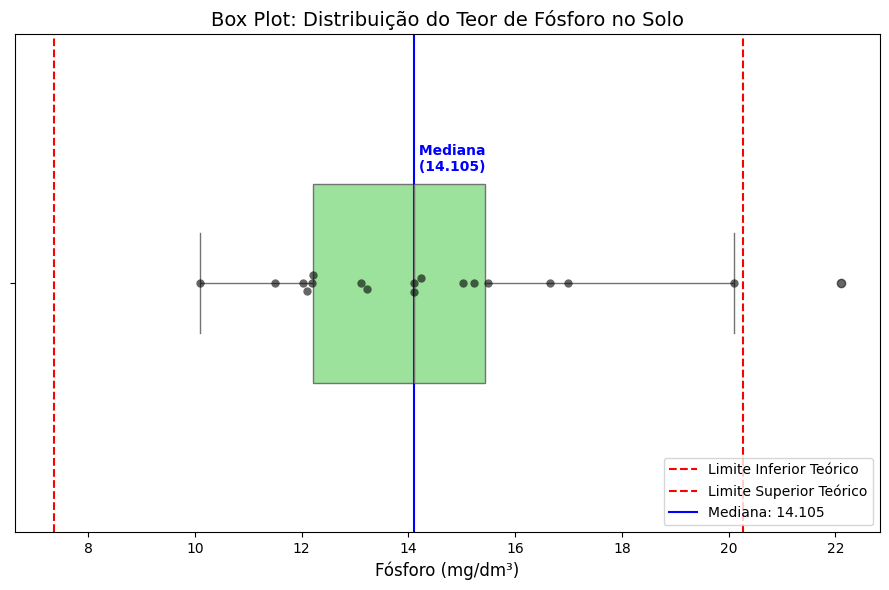

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Simulando um conjunto de dados real: Teor de Fósforo (mg/dm³) em amostras de solo
# Note que inserimos dois valores extremos propositalmente
dados_fosforo = [12.1, 14.1, 15.5, 11.5, 13.23, 16.66, 14.23, 15.02, 12.02, 17.00, 13.12, 15.23, 14.11, 20.11, 12.22, 22.1, 10.1,12.2]
df_solo = pd.DataFrame({'teor_P': dados_fosforo})

# --- 1. A Matemática por trás do Box Plot ---
Q1 = df_solo['teor_P'].quantile(0.25)
Q3 = df_solo['teor_P'].quantile(0.75)
Q2 = df_solo['teor_P'].quantile(0.50)
mediana = df_solo['teor_P'].median()
IQR = Q3 - Q1

LI = Q1 - (1.5 * IQR)
LS = Q3 + (1.5 * IQR)

print("--- Cálculos do Box Plot ---")
print(f"Mínimo Real: {df_solo['teor_P'].min()}")
print(f"1º Quartil (Q1): {Q1}")
print(f"Mediana (Q2): {mediana}")
print(f"2º Quartil (Q2): {Q2}") #2º Quartil = Mediana
print(f"3º Quartil (Q3): {Q3}")
print(f"Máximo Real: {df_solo['teor_P'].max()}")
print(f"Distância Interquartil (dq): {IQR}")
print(f"Limite Inferior Teórico (LI): {LI}")
print(f"Limite Superior Teórico (LS): {LS}")

# Identificando os outliers matematicamente
outliers = df_solo[(df_solo['teor_P'] < LI) | (df_solo['teor_P'] > LS)]
print(f"\nValores Atípicos (Outliers) encontrados:\n{outliers['teor_P'].values}")

# --- 2. O Gráfico Box Plot com Seaborn ---
plt.figure(figsize=(9, 6))

# Criando o box plot na horizontal
sns.boxplot(x=df_solo['teor_P'], color='lightgreen', width=0.4)

# Adicionando o swarmplot
sns.swarmplot(x=df_solo['teor_P'], color='black', alpha=0.6, size=6)

plt.title('Box Plot: Distribuição do Teor de Fósforo no Solo', fontsize=14)
plt.xlabel('Fósforo (mg/dm³)', fontsize=12)

# Adicionando linhas de referência limites
plt.axvline(LI, color='red', linestyle='--', label='Limite Inferior Teórico')
plt.axvline(LS, color='red', linestyle='--', label='Limite Superior Teórico')

# Destacando e adicionando a linha e o texto com o valor da mediana
plt.axvline(mediana, color='blue', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana}')
plt.text(mediana, -0.25, f' Mediana\n ({mediana})', color='blue', fontweight='bold', va='center', ha='left')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Gráficos de Simetria

Muitas vezes, calcular apenas a média e a mediana não é suficiente para "enxergar" o formato dos dados. O gráfico de simetria usa a distância dos pontos até a mediana para testar se a cauda direita (valores maiores) é um reflexo exato da cauda esquerda (valores menores).

**A Lógica (Fórmulas):**
Para cada ponto da amostra, calculamos duas distâncias:
*   **u:** Distância dos valores inferiores até a mediana. (u = Mediana - Valor Inferior)
*   **v:** Distância dos valores superiores até a mediana. (v = Valor Superior - Mediana)

**Como interpretar o gráfico (Plano Cartesiano u vs v):**
*   **Simetria Perfeita:** Os pares (u, v) formam uma linha reta perfeita em um ângulo de 45º (onde v = u).
*   **Assimetria à Direita (Positiva):** Os pontos ficam **acima** da reta vermelha. Significa que a cauda da direita "estica" muito mais longe da mediana (típico de salários, populações ou número de habitantes, onde existem poucos valores muito altos).
*   **Assimetria à Esquerda (Negativa):** Os pontos ficam **abaixo** da reta vermelha. A cauda esquerda é mais longa.
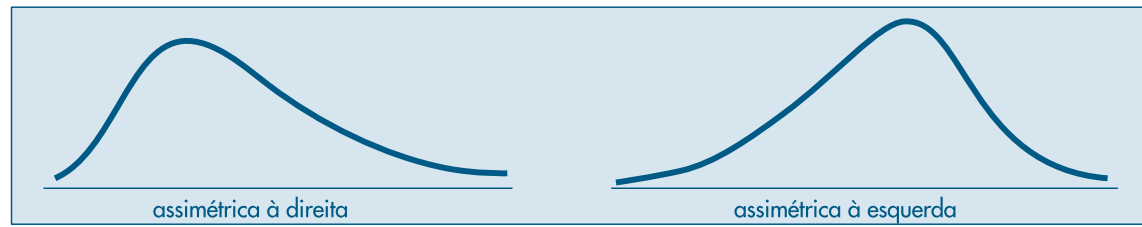

## 10.1. Visualizando a Assimetria (Curvas de Densidade)

Para ter uma noção visual mais clara do formato dos dados, costumamos desenhar uma curva de densidade (uma linha que suaviza o contorno de um histograma). O lado para onde a "cauda" do gráfico se estica define o nome da assimetria.

*   **Assimétrica à Direita (Positiva):** A cauda longa aponta para a direita. A grande massa de dados está espremida nos valores baixos (à esquerda).
    *   *Exemplo clássico:* Salários. A maioria ganha pouco, mas alguns poucos ganham valores absurdamente altos (esticando a cauda para a direita).
    *   *Regra de Ouro:* Média > Mediana > Moda. (Os valores altíssimos puxam a média para cima).

*   **Assimétrica à Esquerda (Negativa):** A cauda longa aponta para a esquerda. A grande massa de dados está concentrada nos valores altos (à direita).
    *   *Exemplo clássico:* Notas de uma prova muito fácil, ou expectativa de vida. A maioria atinge valores altos, mas algumas poucas exceções puxam a cauda para valores muito baixos.
    *   *Regra de Ouro:* Média < Mediana < Moda. (Os valores baixíssimos puxam a média para baixo).

> 💡 **Conexão:** É por causa do "peso" dessas caudas que a Mediana é considerada uma medida resistente, enquanto a Média é facilmente arrastada para o lado da cauda longa!

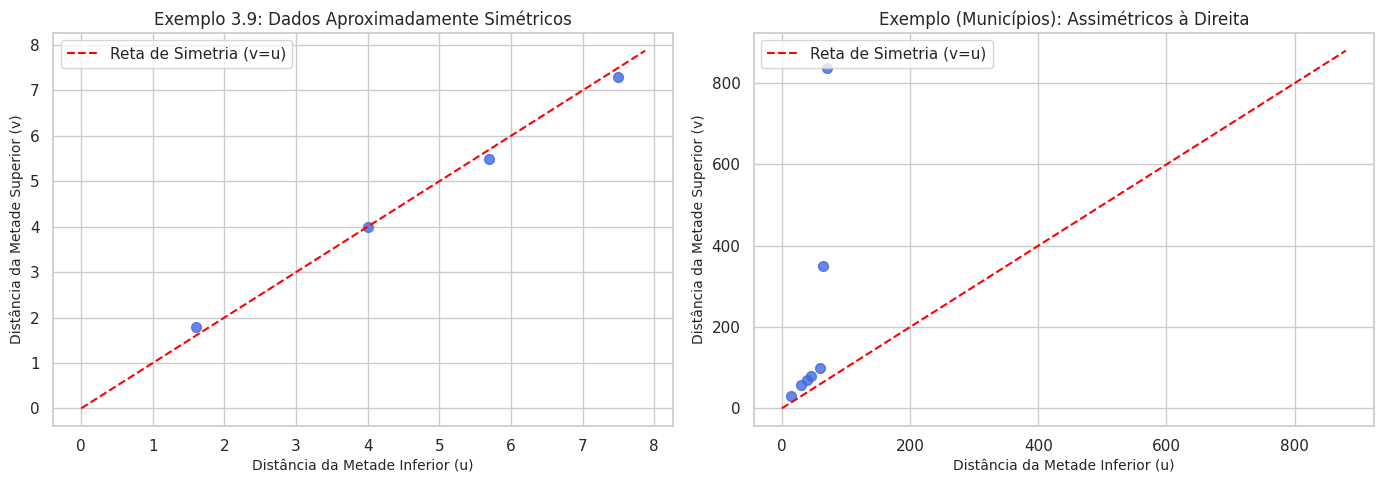

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid")

# --- 1. Criando a Função Reutilizável ---
def plotar_simetria(dados, ax, titulo):
    # Ordena os dados do menor para o maior
    x = np.sort(dados)
    mediana = np.median(x)
    meio = len(x) // 2

    # u: distância dos valores da METADE INFERIOR até a mediana
    u = mediana - x[:meio]

    # v: distância dos valores da METADE SUPERIOR até a mediana
    # o comando [::-1] inverte a lista, pegando do maior valor de volta para o centro
    v = x[::-1][:meio] - mediana

    # Plotando os pontos no plano cartesiano
    ax.scatter(u, v, color='royalblue', alpha=0.8, s=50)

    # Criando a Reta de Referência Perfeita (v = u)
    limite = max(np.max(u), np.max(v)) * 1.05 # Pega o maior valor para esticar a reta
    ax.plot([0, limite], [0, limite], color='red', linestyle='--', label='Reta de Simetria (v=u)')

    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Distância da Metade Inferior (u)', fontsize=10)
    ax.set_ylabel('Distância da Metade Superior (v)', fontsize=10)
    ax.legend()

# --- 2. Preparando os Dados (Exemplos do Livro) ---
# Exemplo 3.9: Dados com simetria quase perfeita
dados_simetricos = np.array([0.5, 2.3, 4.0, 6.4, 8.0, 9.8, 12.0, 13.5, 15.3])

# Exemplo dos Municípios: Altamente assimétricos à direita (Rio e SP são os valores altíssimos no final)
# Simulando as 15 maiores cidades baseadas no padrão do livro
dados_municipios = np.array([80, 85, 90, 105, 110, 120, 135, 150, 180, 208, 220, 230, 250, 500, 988])

# --- 3. Gerando os Gráficos Lado a Lado ---
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

plotar_simetria(dados_simetricos, eixos[0], 'Exemplo 3.9: Dados Aproximadamente Simétricos')
plotar_simetria(dados_municipios, eixos[1], 'Exemplo (Municípios): Assimétricos à Direita')

plt.tight_layout()
plt.show()

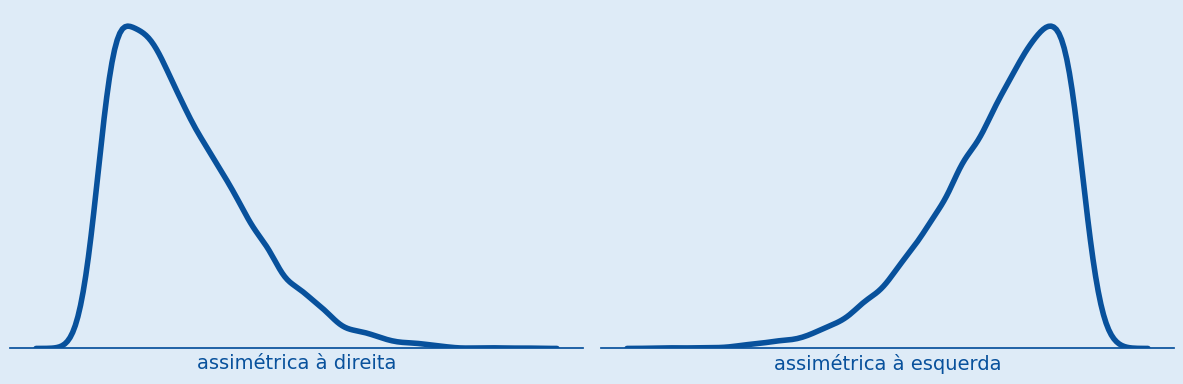

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skewnorm

# 1. Gerando dados teóricos com assimetria
# O parâmetro 'a' define a distorção. a > 0 (direita), a < 0 (esquerda)
dados_direita = skewnorm.rvs(a=10, size=10000, random_state=42)
dados_esquerda = skewnorm.rvs(a=-10, size=10000, random_state=42)

# 2. Configurando o visual para ficar igual ao livro (fundo azul claro)
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
cor_fundo = '#DEEBF7' # Azul bem clarinho
cor_linha = '#08519C' # Azul escuro para a curva

fig.patch.set_facecolor(cor_fundo)

# 3. Desenhando a curva Assimétrica à Direita
sns.kdeplot(dados_direita, ax=eixos[0], color=cor_linha, linewidth=4)
eixos[0].set_facecolor(cor_fundo)
eixos[0].set_xlabel('assimétrica à direita', fontsize=14, color=cor_linha)

# 4. Desenhando a curva Assimétrica à Esquerda
sns.kdeplot(dados_esquerda, ax=eixos[1], color=cor_linha, linewidth=4)
eixos[1].set_facecolor(cor_fundo)
eixos[1].set_xlabel('assimétrica à esquerda', fontsize=14, color=cor_linha)

# 5. Limpando os eixos (removendo bordas e números para focar só no formato, igual à imagem)
for ax in eixos:
    ax.set_ylabel('')
    ax.set_yticks([]) # Remove os números do eixo Y
    ax.set_xticks([]) # Remove os números do eixo X
    # Deixando apenas a linha inferior do eixo
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(cor_linha)

plt.tight_layout()
plt.show()

## 11. Transformações de Dados

Muitos testes estatísticos (e modelos de Machine Learning) exigem que os dados tenham uma distribuição simétrica, parecida com a curva Normal (sino). Quando temos dados com forte assimetria à direita (ex: populações, rendas, áreas de fazendas), os valores extremos "esticam" o gráfico.

Para consertar isso, aplicamos funções matemáticas que "encolhem" os valores gigantes sem alterar a ordem das observações.
As mais comuns para dados positivos assimétricos à direita são:
*   **Transformação Logarítmica (p = 0):** É a mais forte. Puxa muito os extremos. Excelente para dados financeiros ou de população.
*   **Raiz Cúbica (p = 1/3) ou Quadrada (p = 1/2):** Transformação moderada.

> 💡 **Nota:** Se o dado for assimétrico à esquerda, fazemos o oposto: elevamos ao quadrado (p=2) ou ao cubo (p=3) para "esticar" os valores altos.

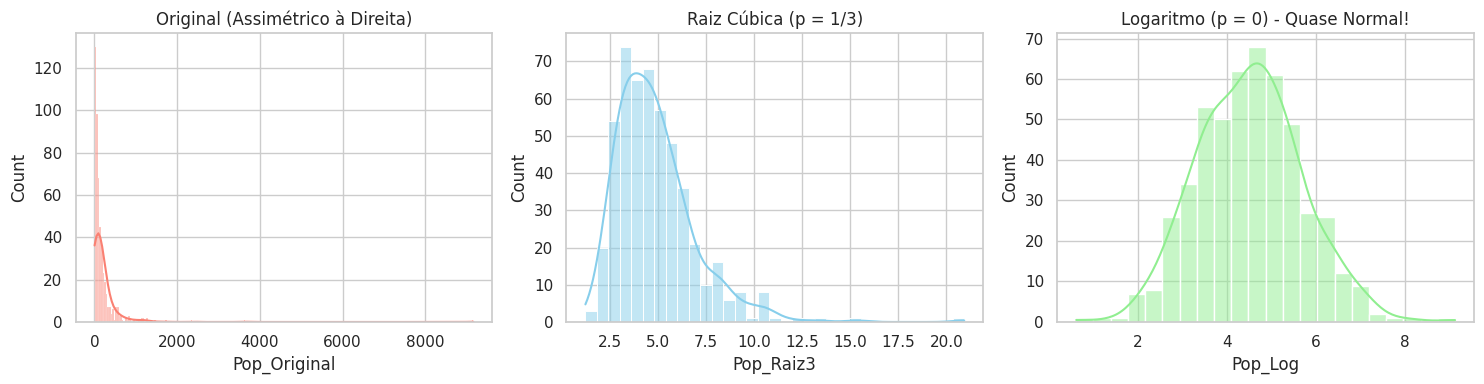

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simulando os dados do CD-Municípios (valores muito assimétricos à direita)
# A maioria tem população baixa (10k a 100k), poucos têm milhões (SP, RJ)
np.random.seed(42)
populacoes = np.random.lognormal(mean=4.5, sigma=1.2, size=500)

df_mun = pd.DataFrame({'Pop_Original': populacoes})

# 1. Aplicando as Transformações
df_mun['Pop_Log'] = np.log(df_mun['Pop_Original'])       # Logaritmo natural
df_mun['Pop_Raiz3'] = np.cbrt(df_mun['Pop_Original'])    # Raiz cúbica

# 2. Visualizando o "Antes e Depois" (Histogramas)
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
sns.set_theme(style="whitegrid")

# Gráfico 1: Original
sns.histplot(df_mun['Pop_Original'], ax=eixos[0], color='salmon', kde=True)
eixos[0].set_title('Original (Assimétrico à Direita)')

# Gráfico 2: Raiz Cúbica
sns.histplot(df_mun['Pop_Raiz3'], ax=eixos[1], color='skyblue', kde=True)
eixos[1].set_title('Raiz Cúbica (p = 1/3)')

# Gráfico 3: Logaritmo
sns.histplot(df_mun['Pop_Log'], ax=eixos[2], color='lightgreen', kde=True)
eixos[2].set_title('Logaritmo (p = 0) - Quase Normal!')

plt.tight_layout()
plt.show()

## 12. Estatísticas Avançadas e Robustas

A seção de problemas do livro introduz métricas que são o padrão-ouro na análise de dados moderna.

**1. Padronização ou Z-Score (Nota Z)**
Mede a quantos Desvios Padrões um valor está afastado da média. Serve para comparar variáveis com unidades diferentes (ex: comparar nota de Matemática com nota de História).
👉 **Fórmula:** Z = (xᵢ - x̄) / dp
*Valores de Z acima de 2 ou abaixo de -2 costumam ser considerados atípicos (outliers).*

**2. Média Aparada (Trimmed Mean)**
Para evitar que outliers puxem a média, nós "aparamos" (cortamos) uma porcentagem das pontas (ex: ignoramos os 10% mais pobres e os 10% mais ricos) e calculamos a média do meio.

**3. Coeficiente de Variação (CV)**
O desvio padrão depende da unidade. O CV transforma o desvio em uma porcentagem da média, permitindo comparar a variabilidade de coisas diferentes (ex: variação de peso de ratos vs elefantes).
👉 **Fórmula:** CV = (dp / x̄) * 100%

**4. Desvio Absoluto Mediano (DAM / MAD)**
É a alternativa ultra-robusta ao Desvio Padrão. Em vez de usar a Média, ele mede a distância de cada ponto até a Mediana.
👉 **Fórmula:** DAM = Mediana( | xᵢ - Mediana(X) | )

In [19]:
import pandas as pd
import numpy as np
from scipy import stats

# Dados do Problema 41 (Velocidade do vento com um grande outlier: 61.1)
ventos = pd.Series([22.2, 61.1, 13.0, 27.8, 22.2, 27.4, 27.4, 27.4,
                    20.4, 20.4, 20.4, 11.1, 13.0, 27.4, 14.8])

print("--- 1. Análise Básica (Afetada pelo outlier) ---")
media = ventos.mean()
dp = ventos.std(ddof=0) # ddof=0 para usar a fórmula populacional do livro
print(f"Média clássica: {media:.2f}")
print(f"Desvio Padrão clássico: {dp:.2f}\n")

print("--- 2. Estatísticas Robustas (Resistentes a outliers) ---")
# Média Aparada a 10% (Corta 10% dos menores e 10% dos maiores)
media_aparada = stats.trim_mean(ventos, proportiontocut=0.10)
print(f"Média Aparada (10%): {media_aparada:.2f}")

# DAM (Desvio Absoluto Mediano) - Scipy chama de median_abs_deviation
# O scale=1 garante que ele não tente ajustar o valor para bater com o desvio padrão normal
dam = stats.median_abs_deviation(ventos, scale=1)
print(f"DAM (Desvio Absoluto Mediano): {dam:.2f}\n")

print("--- 3. Padronização e Comparação ---")
# Coeficiente de Variação (CV)
cv = (dp / media) * 100
print(f"Coeficiente de Variação (CV): {cv:.2f}%")

# Z-Score (Padronização)
# Vamos ver o Z-score do pior outlier (61.1)
z_scores = stats.zscore(ventos)
z_outlier = z_scores[1] # O 61.1 é o segundo item da lista (índice 1)
print(f"O valor 61.1 tem um Z-Score de: {z_outlier:.2f}")
print("-> Como 3.16 é maior que 2, confirmamos matematicamente que é um valor extremo!")

--- 1. Análise Básica (Afetada pelo outlier) ---
Média clássica: 23.73
Desvio Padrão clássico: 11.47

--- 2. Estatísticas Robustas (Resistentes a outliers) ---
Média Aparada (10%): 21.83
DAM (Desvio Absoluto Mediano): 5.20

--- 3. Padronização e Comparação ---
Coeficiente de Variação (CV): 48.34%
O valor 61.1 tem um Z-Score de: 3.26
-> Como 3.16 é maior que 2, confirmamos matematicamente que é um valor extremo!


### Explicação Detalhada do Z-Score (Caso do Outlier 61.1)

O **Z-Score** (ou Nota Z) mede o quão distante um determinado valor está da **média** do grupo, utilizando o **Desvio Padrão** como unidade de medida.

Ele nos diz: *"esta velocidade de vento está a quantos desvios padrões acima ou abaixo da média geral?"*

---

#### 1. A Fórmula Geral do Z-Score

Para qualquer valor $x$ do seu conjunto de dados, o cálculo é definido por:

$$
Z = \frac{x - \mu}{\sigma}
$$

Onde:
* **$x$**: O valor individual analisado ($61.1$).
* **$\mu$** (mi): A **média** de todos os dados ($23.73$).
* **$\sigma$** (sigma): O **desvio padrão** do grupo ($11.47$).

---

#### 2. Aplicando os Números ao seu Caso ($x = 61.1$)

Substituindo os valores calculados pelo Python diretamente na fórmula, temos:

$$
Z = \frac{61.1 - 23.73}{11.47}
$$

Primeiro, calculamos a diferença no numerador (o quanto esse vento se afasta da média):

$$
61.1 - 23.73 = 37.37
$$

Agora, dividimos essa diferença pelo desvio padrão para obter a distância final:

$$
Z = \frac{37.37}{11.47} \approx 3.26
$$

---

#### 3. Como interpretar o resultado?

* **Z-Score = 3.26**: Significa que o vento de $61.1\text{ km/h}$ está a **$3.26$ desvios padrões acima da média**.
* **Regra de Ouro (Identificação de Outliers)**: Na estatística, qualquer valor com um Z-Score **maior que $2.0$** (ou **$3.0$** em critérios mais rígidos) é considerado um ponto extremamente raro e atípico (**outlier**), pois mais de 99% de todos os dados costumam se concentrar a menos de $3$ desvios padrões de distância da média.